# Regla de vecindad espacial (AGEB urbanas, CDMX)
**Objetivo:** definir y justificar la regla de vecindad que se usará en la Fase 3 (Moran global, LISA y Moran bivariado), y documentar sus implicaciones.

El PDF exige definir la regla de vecindad y explicar qué implica para los resultados. Aquí construimos los vecinos, medimos cuántas AGEB quedan **aisladas** (islas) y comparamos dos reglas: contigüidad *Queen* y *k vecinos más cercanos*.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from libpysal.weights import Queen, KNN
from src.config import ROOT, PROCESSED_DIR
from src.geo.polygons import load_agebs

agebs = load_agebs().reset_index(drop=True)
print("AGEB urbanas:", len(agebs), "| CRS:", agebs.crs.name)

AGEB urbanas: 2431 | CRS: MEXICO_ITRF_2008_LCC


## 1. Contigüidad Queen
Dos AGEB son vecinas si comparten **un borde o una esquina**. Es la regla más usual para unidades de área (polígonos) y no depende de un parámetro.

In [2]:
w_q = Queen.from_dataframe(agebs, use_index=False, silence_warnings=True)

resumen_q = pd.Series({
    "AGEB (n)": w_q.n,
    "Islas (sin vecinos)": len(w_q.islands),
    "Vecinos mínimo": w_q.min_neighbors,
    "Vecinos promedio": round(w_q.mean_neighbors, 2),
    "Vecinos máximo": w_q.max_neighbors,
    "Componentes conectados": w_q.n_components,
})
resumen_q

AGEB (n)                  2431.00
Islas (sin vecinos)          1.00
Vecinos mínimo               0.00
Vecinos promedio             5.93
Vecinos máximo              26.00
Componentes conectados       6.00
dtype: float64

0       1
1      25
2      47
3     131
4     333
5     523
6     554
7     385
8     218
9     107
10     50
11     21
12     13
13      8
14      4
15      2
16      5
17      2
22      1
26      1


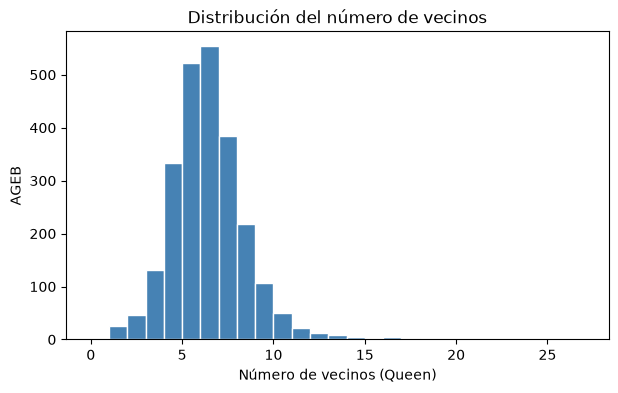

In [3]:
cardinalidad = pd.Series(w_q.cardinalities)
print(cardinalidad.value_counts().sort_index().to_string())

fig, ax = plt.subplots(figsize=(7, 4))
cardinalidad.plot(kind="hist", bins=range(0, int(cardinalidad.max()) + 2), ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Número de vecinos (Queen)")
ax.set_ylabel("AGEB")
ax.set_title("Distribución del número de vecinos")
plt.show()

## 2. ¿Dónde están las islas?
Una isla es una AGEB sin vecinos. En una ciudad con zonas rurales, cerros o cuerpos de agua es normal que algunas queden separadas. Con pocas islas, la regla funciona; con muchas, hay que cambiar de regla.

In [4]:
islas = agebs.iloc[w_q.islands].copy()
print("Islas:", len(islas))
islas[["CVEGEO"]].head(10)

Islas: 1


,CVEGEO
1649,090090015012A


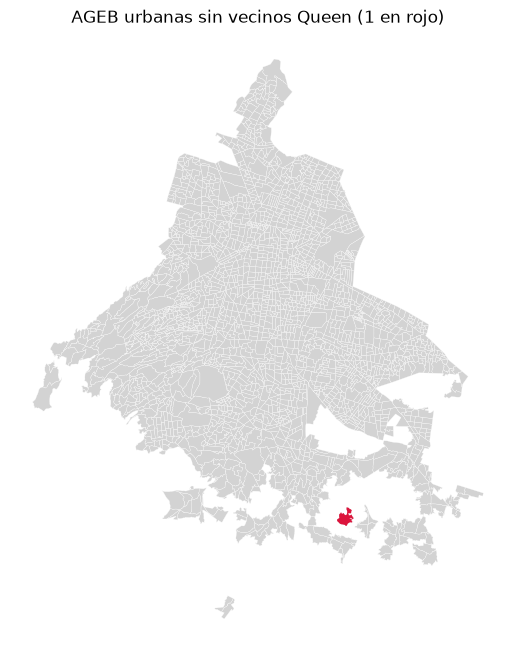

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))
agebs.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.2)
if len(islas):
    islas.plot(ax=ax, color="crimson")
ax.set_title(f"AGEB urbanas sin vecinos Queen ({len(islas)} en rojo)")
ax.set_axis_off()

out_dir = ROOT / "outputs" / "maps"
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / "vecindad_islas_queen.png", dpi=150, bbox_inches="tight")
plt.show()

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
islas[["CVEGEO"]].to_csv(PROCESSED_DIR / "ageb_islas_queen.csv", index=False)

## 3. Alternativa: k vecinos más cercanos (KNN)
KNN conecta cada AGEB con sus *k* centroides más cercanos. **No genera islas** por construcción, pero conecta AGEB que no son contiguas y fija el mismo número de vecinos para todas.

In [6]:
K = 6
w_k = KNN.from_dataframe(agebs, k=K, use_index=False)

comparacion = pd.DataFrame({
    "Queen": {
        "Islas": len(w_q.islands),
        "Vecinos mín": w_q.min_neighbors,
        "Vecinos prom": round(w_q.mean_neighbors, 2),
        "Vecinos máx": w_q.max_neighbors,
        "Componentes conectados": w_q.n_components,
    },
    f"KNN (k={K})": {
        "Islas": len(w_k.islands),
        "Vecinos mín": w_k.min_neighbors,
        "Vecinos prom": round(w_k.mean_neighbors, 2),
        "Vecinos máx": w_k.max_neighbors,
        "Componentes conectados": w_k.n_components,
    },
})
comparacion

,Queen,KNN (k=6)
Islas,1.00,0.0
Vecinos mín,0.00,6.0
Vecinos prom,5.93,6.0
Vecinos máx,26.00,6.0
Componentes conectados,6.00,1.0


In [7]:
import pandas as pd

# 1) Tamaño de los componentes conectados
etiquetas = pd.Series(w_q.component_labels)
print(etiquetas.value_counts().to_string())

# 2) Las AGEB con más vecinos
top = pd.Series(w_q.cardinalities).sort_values(ascending=False).head(5)
print(agebs.iloc[top.index][["CVEGEO", "area_km2"]].assign(vecinos=top.values).to_string())


0    2404
1      16
4       5
3       3
2       2
5       1
             CVEGEO  area_km2  vecinos
733   0901700010140  7.431910       26
1285  0900500012165  2.989406       22
1824  0900300010906  0.768796       17
1288  0901600010798  2.895648       17
1967  0900300010770  7.250259       16


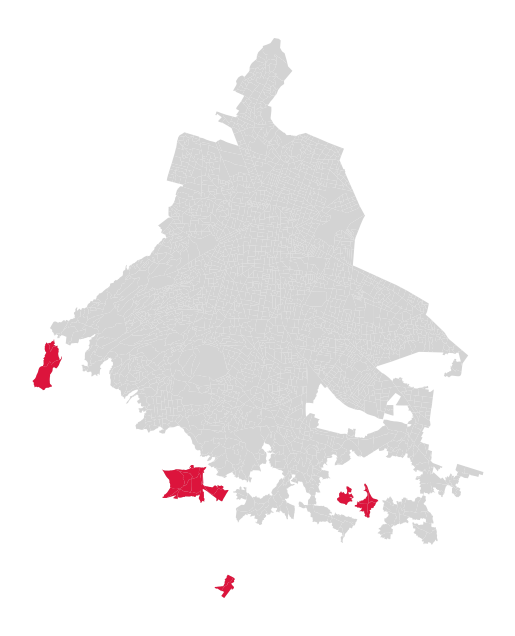

In [8]:
etiquetas = pd.Series(w_q.component_labels, index=agebs.index)
principal = etiquetas.value_counts().idxmax()
fuera = agebs[etiquetas != principal]
ax = agebs.plot(color="lightgrey", figsize=(8, 8))
fuera.plot(ax=ax, color="crimson")
ax.set_axis_off()

## 4. Decisión y implicaciones (completar con los resultados)

Regla elegida: contigüidad Queen de primer orden, con pesos estandarizados por fila.

Justificación: de 2,431 AGEB, solo 1 (0.04%) queda sin vecinos y 2,404 (98.9%) forman un único componente conectado. El promedio es de 5.93 vecinos, en un rango de 0 a 26. La AGEB con más vecinos (0901700010140, 7.43 km²) es atípicamente grande.

Tratamiento de la isla: se excluye de Moran y LISA, porque sin vecinos su rezago espacial no está definido y representa el 0.04% de las unidades.

Conectividad: además del componente principal, hay cuatro grupos aislados de 16, 5, 3 y 2 AGEB. El rezago espacial se calcula solo dentro de cada componente, así que un cluster no se propaga entre ellos.

Robustez: el análisis puede repetirse con KNN (k=6), que conecta todo en un solo componente, para comprobar que los clusters no dependan de la regla.

Implicaciones: los resultados de Moran y LISA dependen de la regla de vecindad. Las AGEB de borde tienen menos vecinos y su rezago es menos estable. La asociación espacial no implica causalidad.